<a href="https://colab.research.google.com/github/gauri-vig/Byte2Beat-ML-model/blob/main/CVD_DISEASE_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving Datasets-20260205T192237Z-1-001.zip to Datasets-20260205T192237Z-1-001 (1).zip


In [ ]:
!ls
!ls Datasets-20260205T192237Z-1-001.zip

 Datasets				    Datasets-20260205T192237Z-1-001.zip
'Datasets-20260205T192237Z-1-001 (1).zip'   sample_data
Datasets-20260205T192237Z-1-001.zip


In [ ]:
!unzip Datasets-20260205T192237Z-1-001.zip -d dataset


Archive:  Datasets-20260205T192237Z-1-001.zip
  inflating: dataset/Datasets/ECG Timeseries/ecg_timeseries.csv  
  inflating: dataset/Datasets/Heart Attack/heart_processed.csv  
  inflating: dataset/Datasets/Cardiac Failure/cardiac_failure_processed.csv  
  inflating: dataset/Datasets/Cardiac Failure/cardio_base.csv  


In [ ]:
import pandas as pd

path = "dataset/Datasets/Heart Attack/heart_processed.csv"

df = pd.read_csv(path)

df.head()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    int64  
 2   Cholesterol        918 non-null    int64  
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   HeartDisease       918 non-null    int64  
 7   Sex_M              918 non-null    bool   
 8   ChestPainType_ATA  918 non-null    bool   
 9   ChestPainType_NAP  918 non-null    bool   
 10  ChestPainType_TA   918 non-null    bool   
 11  RestingECG_Normal  918 non-null    bool   
 12  RestingECG_ST      918 non-null    bool   
 13  ExerciseAngina_Y   918 non-null    bool   
 14  ST_Slope_Flat      918 non-null    bool   
 15  ST_Slope_Up        918 non-null    bool   
dtypes: bool(9), float64(1), in

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

#reproducibility

import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


In [ ]:
df = pd.read_csv(
    "dataset/Datasets/Heart Attack/heart_processed.csv"
)

print(df.shape)
df.head()
print(df.columns)


(918, 16)
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


In [ ]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)


In [ ]:
class HeartNet(nn.Module):

    def __init__(self, input_size):
        super(HeartNet, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 2)   # Binary classification
        )

    def forward(self, x):
        return self.net(x)


input_size = X_train.shape[1]

model = HeartNet(input_size)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
epochs = 100

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()

    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [10/100], Loss: 0.2069
Epoch [20/100], Loss: 0.1918
Epoch [30/100], Loss: 0.2063
Epoch [40/100], Loss: 0.2082
Epoch [50/100], Loss: 0.1773
Epoch [60/100], Loss: 0.2011
Epoch [70/100], Loss: 0.1812
Epoch [80/100], Loss: 0.1669
Epoch [90/100], Loss: 0.1870
Epoch [100/100], Loss: 0.1770


In [ ]:
model.eval()

with torch.no_grad():

    outputs = model(X_test)

    _, predicted = torch.max(outputs, 1)

print("\nClassification Report:\n")

print(classification_report(y_test, predicted))



Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



In [ ]:
def train_model_for_dataset(df, target_col, name, epochs=100):

    print(f"\n Training {name}")
    print(f"Target Column: {target_col}")

    # Remove unwanted index column
    if "Unnamed: 0" in df.columns:
        df = df.drop("Unnamed: 0", axis=1)

    # Split X and y
    X = df.drop(target_col, axis=1)
    y = df[target_col]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Scale
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Convert to Torch
    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)

    y_train = torch.tensor(y_train.values, dtype=torch.long)
    y_test = torch.tensor(y_test.values, dtype=torch.long)

    # Model
    input_size = X_train.shape[1]

    model = HeartNet(input_size)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training loop
    for epoch in range(epochs):

        model.train()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch+1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

    # Evaluation
    model.eval()

    with torch.no_grad():
        outputs = model(X_test)
        _, predicted = torch.max(outputs, 1)

    print("\n📊 Classification Report:\n")
    print(classification_report(y_test, predicted))

    return model, scaler


In [ ]:
heart_model, heart_scaler = train_model_for_dataset(
    heart_df,
    "HeartDisease",
    "Heart Disease Dataset"
)
cardio_model, cardio_scaler = train_model_for_dataset(
    failure_df,
    "cardio",
    "Cardio Dataset"
)



 Training Heart Disease Dataset
Target Column: HeartDisease
Epoch [10/100], Loss: 0.6080
Epoch [20/100], Loss: 0.5200
Epoch [30/100], Loss: 0.4374
Epoch [40/100], Loss: 0.3764
Epoch [50/100], Loss: 0.3426
Epoch [60/100], Loss: 0.3220
Epoch [70/100], Loss: 0.3255
Epoch [80/100], Loss: 0.3201
Epoch [90/100], Loss: 0.3087
Epoch [100/100], Loss: 0.2976

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.82      0.86        82
           1       0.86      0.93      0.90       102

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.88       184
weighted avg       0.88      0.88      0.88       184


 Training Cardio Dataset
Target Column: cardio
Epoch [10/100], Loss: 0.6673
Epoch [20/100], Loss: 0.6483
Epoch [30/100], Loss: 0.6376
Epoch [40/100], Loss: 0.6332
Epoch [50/100], Loss: 0.6307
Epoch [60/100], Loss: 0.6277
Epoch [70/100], Loss: 0.6248
Epoch [80/100], Loss: 0.6238
Epoch [90/100]

In [ ]:
torch.save(heart_model.state_dict(), "heart_model.pth")
torch.save(cardio_model.state_dict(), "cardio_model.pth")


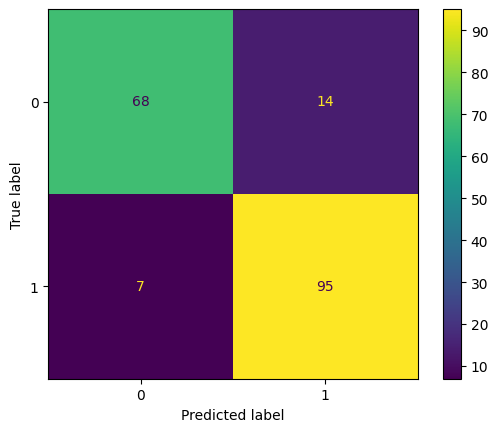

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predicted)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
